# 3.4.2 PLE 渐进式专家抽取

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如果共享专家仍让任务互相干扰，怎样显式保留任务专属知识，并逐层控制共享？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Tang et al., 2020, PLE](https://dl.acm.org/doi/10.1145/3383313.3412236)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance)
DATASET_KEY = "kuairand"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 39098, 'users_used': 128, 'items_used': 2500, 'time_min_utc': '2022-04-09T04:17:39+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如果共享专家仍让任务互相干扰，怎样显式保留任务专属知识，并逐层控制共享？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

PLE 每层同时维护共享专家和任务专属专家，用 CGC 门控逐层抽取。它给“不该共享的知识”明确位置，目标是缓解负迁移与跷跷板；代价是结构与调参更复杂。

**来源：** [Tang et al., 2020, PLE](https://dl.acm.org/doi/10.1145/3383313.3412236)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Model Structure & Formula Walkthrough


### 结构：共享专家之外，再给每个任务专属空间

第 $l$ 层中，任务 $k$ 只混合自己的专家 $E_k^{(l)}$ 与共享专家 $E_s^{(l)}$：

$$z_k^{(l)}=\sum_{e\in E_k^{(l)}\cup E_s^{(l)}}g_{k,e}^{(l)}f_e^{(l)}(z^{(l-1)}).$$

共享 gate 则读取所有任务与共享专家，为下一层产生公共表示。重复多层称为 progressive extraction：越往后，公共信息与任务特有信息的边界越清楚。最终仍是每任务 tower、Sigmoid 与 $L=\sum_k\lambda_kL_k$。与 MMoE 的关键差异不是损失，而是限制“哪些专家允许被哪个 gate 读取”。

### 公式到代码

`run_ple` 保持与 MMoE 相同数据和目标，仅替换为 Torch-RecHub PLE；这样结果差异才主要来自 CGC 结构而非样本口径。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

任务 gate 只从共享专家和自己的专属专家中选择；共享 gate 汇总所有专家供下一层使用。层层重复后，共享信息逐步提纯。直觉上像公共课和专业课：都听公共课，但不被迫共享全部专业细节。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

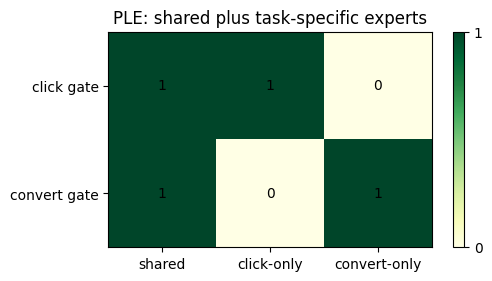

In [2]:
import numpy as np, matplotlib.pyplot as plt
matrix=np.array([[1,1,0],[1,0,1]],dtype=float); fig,ax=plt.subplots(figsize=(5.5,2.8)); image=ax.imshow(matrix,cmap='YlGn')
ax.set_xticks(range(3),['shared','click-only','convert-only']); ax.set_yticks(range(2),['click gate','convert gate'])
for i in range(2):
    for j in range(3): ax.text(j,i,int(matrix[i,j]),ha='center',va='center')
ax.set_title('PLE: shared plus task-specific experts'); plt.colorbar(image,ax=ax,ticks=[0,1]); plt.show()

## Data

与 MMoE 完全相同的 KuaiRand-Pure 真实曝光行、时间切分和 `is_click`/`long_view` 目标，保证横向口径一致。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.multi_task.PLE，执行两层 CGC、共享/专属专家与任务塔；full profile 映射 TorchEasyRec PLE。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_ple, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_ple))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_ple(epochs: int = 28) -> dict: return _run_multitask("ple", epochs)



## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_ple()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '共享/专属专家逐层计算，各任务塔输出；服务关注参数量、专家并行和输出版本兼容。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.multi_task.PLE', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 8000, 'features': 22, 'tasks': ['observed is_click', 'observed long_view']}}
inference contract: 共享/专属专家逐层计算，各任务塔输出；服务关注参数量、专家并行和输出版本兼容。
loss: 1.544 → 0.8192


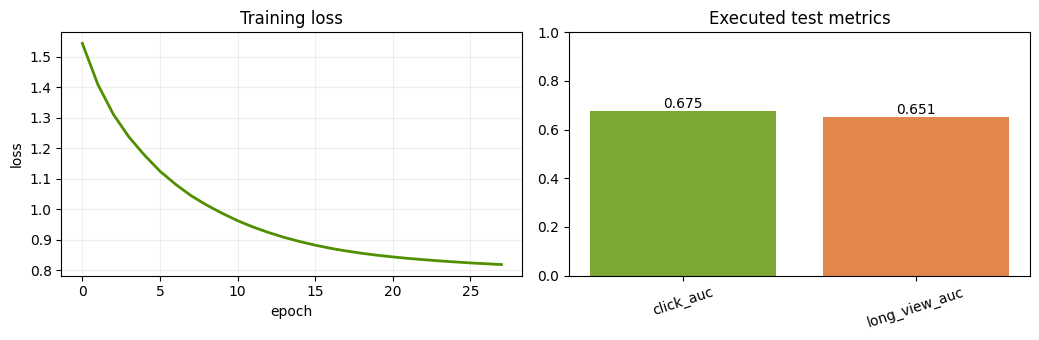

,value
click_auc,0.674826
long_view_auc,0.650834


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'click_auc': result['click_auc'], 'long_view_auc': result['long_view_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 click_auc = **{result['click_auc']:.4f}**。
- 辅助指标 long_view_auc = **{result['long_view_auc']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 简单或小数据上 PLE 可能不如 MMoE；复杂结构只有在负迁移真实存在且数据充足时才可能回本。

### 工业边界

共享/专属专家逐层计算，各任务塔输出；服务关注参数量、专家并行和输出版本兼容。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 click_auc = **0.6748**。
- 辅助指标 long_view_auc = **0.6508**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.5440** 降到 **0.8192**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 简单或小数据上 PLE 可能不如 MMoE；复杂结构只有在负迁移真实存在且数据充足时才可能回本。

### 工业边界

共享/专属专家逐层计算，各任务塔输出；服务关注参数量、专家并行和输出版本兼容。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'PLE 渐进式专家抽取',
    'primary_metric': 'click_auc', 'primary_value': float(result['click_auc']),
    'secondary_metric': 'long_view_auc', 'secondary_value': float(result['long_view_auc']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '3_4_2_ple',
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_4','3_4_2_ple',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_4/3_4_2_ple.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['click_auc']) <= 1
assert np.isfinite(float(result['long_view_auc']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。